# 🚀 Practice Day 17

**📅 Date:** 2026-09-28  
**📁 Category:** Phase 1 · 데이터 클리닝 (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Diagnose data quality issues in a messy survey dataset (missing values, duplicates, type errors, inconsistent categories, outliers)
  (지저분한 설문 데이터의 품질 문제 진단: 결측치·중복행·타입 오류·표기 불일치·이상값)
- Clean the dataset so it's reliable enough to analyze
  (분석 가능한 수준으로 데이터 정제하기)
- Summarize satisfaction ratings by department once the data is clean
  (정제 후 부서별 만족도 요약하기)

---
# 📂 Dataset

**Dataset Name:** TechNova Inc. — 2024 Employee Engagement Survey (Raw) / 직원 만족도 설문조사 (원본, 지저분한 버전)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** 270 raw survey responses collected over a one-month internal engagement survey. Two teams exported and merged their response logs, so the file carries the data-quality issues typical of that process: missing values, some exact duplicate rows, an `age` column mixing numbers with junk text, inconsistent capitalization/spacing in `gender` and `department`, and a few out-of-range values.
(한 달간 진행된 사내 만족도 설문조사에서 두 팀이 각각 취합한 응답 로그를 합치면서 생긴 품질 문제가 포함된 270건의 원본 응답 데이터입니다. 결측치, 완전 중복행, 숫자와 문자가 섞인 `age` 컬럼, `gender`·`department`의 대소문자/공백 표기 불일치, 범위를 벗어난 이상값이 의도적으로 섞여 있습니다.)

## Dataset Preview

In [302]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

# --- Generate base survey responses (Employee Engagement Survey) ---
n_clean = 258
n_dupe = 12

departments = ['Sales', 'Marketing', 'Engineering', 'HR', 'Finance', 'Customer Support']
dept_weights = [0.22, 0.15, 0.28, 0.10, 0.13, 0.12]

genders = ['Male', 'Female', 'Non-binary']
gender_weights = [0.47, 0.47, 0.06]

ages = np.random.normal(38, 10, n_clean).round().astype(int)
ages = np.clip(ages, 22, 63)

ratings = np.random.choice([1, 2, 3, 4, 5], size=n_clean, p=[0.05, 0.10, 0.25, 0.35, 0.25])
dept_choices = np.random.choice(departments, size=n_clean, p=dept_weights)
gender_choices = np.random.choice(genders, size=n_clean, p=gender_weights)
dates = pd.to_datetime('2024-11-01') + pd.to_timedelta(np.random.randint(0, 30, size=n_clean), unit='D')

df = pd.DataFrame({
    'response_id': [f'R{i:04d}' for i in range(1, n_clean + 1)],
    'age': ages,
    'gender': gender_choices,
    'department': dept_choices,
    'satisfaction_rating': ratings,
    'response_date': dates
})

df['age'] = df['age'].astype(object)
df['satisfaction_rating'] = df['satisfaction_rating'].astype(object)
df['response_date'] = df['response_date'].astype(object)

rng = np.random.default_rng(42)

# --- Inject realistic messiness (this is what you'll clean up below) ---

# 1) Inconsistent text formatting: gender casing/whitespace
gender_variants = {
    'Male': ['male', 'MALE', ' Male', 'Male '],
    'Female': ['female', 'FEMALE', ' Female', 'Female '],
    'Non-binary': ['non-binary', 'NON-BINARY', ' Non-binary', 'Non-Binary ']
}
mess_idx = rng.choice(df.index, size=int(n_clean * 0.45), replace=False)
for i in mess_idx:
    df.loc[i, 'gender'] = rng.choice(gender_variants[df.loc[i, 'gender']])

# 2) Inconsistent text formatting: department casing/whitespace
mess_idx2 = rng.choice(df.index, size=int(n_clean * 0.45), replace=False)
for i in mess_idx2:
    base = df.loc[i, 'department']
    df.loc[i, 'department'] = rng.choice([base.lower(), base.upper(), ' ' + base, base + ' '])

# 3) age: non-numeric junk values + unrealistic outliers
used_idx = set()
age_junk_vals = ['unknown', 'N/A', '-', 'twenty-nine']
junk_idx = rng.choice(df.index, size=10, replace=False)
used_idx.update(junk_idx.tolist())
for j, i in enumerate(junk_idx):
    df.loc[i, 'age'] = age_junk_vals[j % len(age_junk_vals)]

avail = df.index.difference(list(used_idx))
outlier_idx = rng.choice(avail, size=8, replace=False)
used_idx.update(outlier_idx.tolist())
outlier_vals = [5, 14, 117, 150, -3, 9, 121, -8]
for j, i in enumerate(outlier_idx):
    df.loc[i, 'age'] = outlier_vals[j % len(outlier_vals)]

# 4) satisfaction_rating: values outside the valid 1-5 scale
outrange_idx = rng.choice(df.index, size=6, replace=False)
outrange_vals = [0, 6, 7, -1, 8, 0]
for j, i in enumerate(outrange_idx):
    df.loc[i, 'satisfaction_rating'] = outrange_vals[j % len(outrange_vals)]

# 5) Missing values scattered across columns
age_avail = df.index.difference(list(used_idx))
df.loc[rng.choice(age_avail, size=10, replace=False), 'age'] = np.nan
for col, n_missing in [('gender', 8), ('department', 8), ('satisfaction_rating', 7), ('response_date', 8)]:
    df.loc[rng.choice(df.index, size=n_missing, replace=False), col] = np.nan

# 6) Duplicate rows (simulates two survey exports being merged with overlap)
dupe_rows = df.sample(n=n_dupe, random_state=7)
df = pd.concat([df, dupe_rows], ignore_index=True)

# Shuffle so duplicates aren't sitting next to their source row
df = df.sample(frac=1, random_state=99).reset_index(drop=True)

df.head(10)


,response_id,age,gender,department,satisfaction_rating,response_date
0,R0027,26,Male,Sales,5,2024-11-29 00:00:00
1,R0033,38,NaN,Engineering,5,2024-11-10 00:00:00
2,R0223,45,Male,Sales,5,2024-11-27 00:00:00
3,R0107,57,Male,Marketing,4,2024-11-10 00:00:00
4,R0154,40,female,Engineering,5,2024-11-17 00:00:00
5,R0004,53,Female,Marketing,NaN,2024-11-18 00:00:00
6,R0041,45,Male,HR,2,2024-11-02 00:00:00
7,R0064,N/A,Male,HR,5,2024-11-30 00:00:00
8,R0073,38,female,Engineering,3,2024-11-27 00:00:00
9,R0234,31,Male,Engineering,4,2024-11-06 00:00:00


## Dataset Information

In [303]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   response_id          270 non-null    str   
 1   age                  259 non-null    object
 2   gender               262 non-null    str   
 3   department           262 non-null    str   
 4   satisfaction_rating  261 non-null    object
 5   response_date        262 non-null    object
dtypes: object(3), str(3)
memory usage: 12.8+ KB

Shape: (270, 6)


,response_id,age,gender,department,satisfaction_rating,response_date
count,270,259,262,262,261,262
unique,258,50,15,28,10,30
top,R0213,41,Male,Engineering,4,2024-11-27 00:00:00
freq,2,16,72,48,83,19


---
# ❓ Business Questions

1. **(Analysis)** How many missing values exist in each column, and how many exact duplicate rows are in the dataset?
   (각 컬럼별 결측치 개수와 데이터셋 내 완전 중복행의 개수는 몇 건인가?)
2. **(Analysis)** How many rows have a non-numeric / invalid `age` value, and what inconsistent formats show up in the `gender` and `department` columns?
   (`age` 컬럼에서 숫자로 변환되지 않는 값은 몇 건이며, `gender`와 `department` 컬럼에는 어떤 표기 불일치가 나타나는가?)
3. **(Analysis)** Among valid numeric ages, how many fall outside a realistic working-age range, and how many `satisfaction_rating` values fall outside the valid 1–5 scale?
   (유효한 숫자형 `age` 중 현실적인 근무 연령대를 벗어난 값과, `satisfaction_rating`이 1~5 범위를 벗어난 값은 각각 몇 건인가?)
4. **(Visualization)** After cleaning, what is the average satisfaction rating by department?
   (정제 후, 부서별 평균 만족도는?)
5. **(Visualization)** After cleaning, what does the overall distribution of satisfaction ratings look like?
   (정제 후, 전체 만족도 점수의 분포는 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — `np.where`, `np.nan`
  (조건부 값 바꾸기, 결측값 지정)
- [x] Pandas — `isnull`, `duplicated`, `drop_duplicates`, `to_numeric(errors='coerce')`, `str.strip().str.upper()`, `between`, `groupby().mean()`
  (결측·중복 확인, 중복 제거, 숫자 변환, 문자 정리, 범위 확인, 그룹별 평균)
- [ ] SQL
- [x] Matplotlib — `ax.bar`, `ax.hist`
  (막대 차트, 히스토그램)
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — `age` 11, `gender` 8, `department` 8, `satisfaction_rating` 9, `response_date` 8
  (결측: age 11, gender 8, department 8, satisfaction_rating 9, response_date 8)
- [x] Duplicate Rows — 12
  (중복 행 12건)
- [x] Wrong Data Types — `age`, `satisfaction_rating`, and `response_date` are `object`
  (age, satisfaction_rating, response_date가 object 타입)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [304]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
response_id             0
age                    11
gender                  8
department              8
satisfaction_rating     9
response_date           8
dtype: int64

Duplicate rows: 12

Dtypes
response_id               str
age                    object
gender                    str
department                str
satisfaction_rating    object
response_date          object
dtype: object

Column names
['response_id', 'age', 'gender', 'department', 'satisfaction_rating', 'response_date']

Text columns — unique counts
response_id            258
age                     50
gender                  15
department              28
satisfaction_rating     10
response_date           30
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** How many missing values exist in each column, and how many exact duplicate rows are in the dataset? (각 컬럼별 결측치 개수와 완전 중복행의 개수는?)

**Result:** Missing values: `age` **11**, `gender` **8**, `department` **8**, `satisfaction_rating` **9**, `response_date` **8**, and `response_id` **0**. There are **12** exact duplicate rows.
(결측치: age 11, gender 8, department 8, satisfaction_rating 9, response_date 8, response_id 0. 완전 중복행은 12건)

**Insight:** Almost every column has some missing values, and the duplicates are probably from the two team exports being merged. The duplicates must be removed before counting anything.
(response_id를 뺀 거의 모든 컬럼에 결측이 있고, 중복은 두 팀의 응답 로그를 합칠 때 생긴 것으로 보임. 무엇이든 세기 전에 중복을 먼저 제거해야 함)

In [305]:
# Question 1: missing values per column + exact duplicate row count
# Hint: df.isnull().sum(), df.duplicated().sum()

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values
response_id             0
age                    11
gender                  8
department              8
satisfaction_rating     9
response_date           8
dtype: int64

Duplicate rows: 12


In [306]:
# Cleaned copy: df stays as the raw table, df_clean is where fixes go
df_clean = df.drop_duplicates().copy()

print("Duplicate rows in df:", df.duplicated().sum())
print("Duplicate rows in df_clean:", df_clean.duplicated().sum())

Duplicate rows in df: 12
Duplicate rows in df_clean: 0


## Question 2

**Question:** How many rows have a non-numeric / invalid `age` value, and what inconsistent formats show up in the `gender` and `department` columns? (`age`에서 숫자로 변환되지 않는 값과 `gender`/`department`의 표기 불일치는?)

**Result:** **8** rows have a non-numeric `age` (`N/A` 3, `unknown` 3, `-` 2). `twenty-nine` was fixed to 29 by hand. After removing duplicates, `age` NaN count went from **10** to **18**. `gender` had 16 spellings (including NaN) and `department` had 29 spellings (including NaN) because of capitalization and extra spaces. After `strip` and `upper`, they became 4 and 7 values (including NaN).
(age에서 숫자가 아닌 값은 8건(N/A 3, unknown 3, - 2). twenty-nine은 직접 29로 바꿈. 중복 제거 후 age NaN은 10에서 18로 늘어남. gender는 대소문자·공백 때문에 16가지(NaN 포함), department는 29가지(NaN 포함)였고, strip과 upper 후 각각 4가지, 7가지(NaN 포함)가 됨)

**Insight:** Without cleaning, one real group is split into many labels (for example `Sales`, `sales`, ` Sales`), so a `groupby` would give wrong results. Junk text in `age` also blocks any numeric calculation.
(정리하지 않으면 실제로는 하나인 그룹이 여러 라벨로 쪼개져(예: Sales, sales, ` Sales`) groupby 결과가 틀려짐. age의 문자 값도 숫자 계산을 막음)

In [307]:
# Question 2: invalid age values + gender/department formatting inconsistencies
# Hint: pd.to_numeric(df['age'], errors='coerce'), df['gender'].unique(), df['department'].unique()

# raw age for the same rows as df_clean (so this cell can be re-run safely)
age_before = df.drop_duplicates()['age']

print(age_before.unique())
print("\nage unique count", len(age_before.unique()))
print("\nage null count", age_before.isnull().sum())

df_clean['age'] = np.where(age_before == 'twenty-nine', 29, age_before)
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

print("\n", df_clean['age'].unique())
print("\nage unique count", len(df_clean['age'].unique()))
print("\nage null count", df_clean['age'].isnull().sum())

# rows that had a value before but became NaN (twenty-nine -> 29 is not counted)
invalid_age = age_before.notna() & df_clean['age'].isna()
print("\nnon-numeric age rows:", invalid_age.sum())
print(age_before[invalid_age].value_counts())

[26 38 45 57 40 53 'N/A' 31 59 32 49 nan 22 41 '-' 48 51 33 46 42 35
 'unknown' 29 27 47 39 30 44 54 36 34 37 -8 43 25 28 -3 52 'twenty-nine'
 14 63 150 56 24 61 9 60 23 117 121 5]

age unique count 51

age null count 10

 [ 26.  38.  45.  57.  40.  53.  nan  31.  59.  32.  49.  22.  41.  48.
  51.  33.  46.  42.  35.  29.  27.  47.  39.  30.  44.  54.  36.  34.
  37.  -8.  43.  25.  28.  -3.  52.  14.  63. 150.  56.  24.  61.   9.
  60.  23. 117. 121.   5.]

age unique count 47

age null count 18

non-numeric age rows: 8
age
N/A        3
unknown    3
-          2
Name: count, dtype: int64


In [308]:
print(df['gender'].unique())
print("\n", df['department'].unique())

df_clean['gender'] = df_clean['gender'].str.strip().str.upper()
df_clean['department'] = df_clean['department'].str.strip().str.upper()

print("\n", df_clean['gender'].unique())
print("\n", df_clean['department'].unique())

<StringArray>
[       'Male',           nan,       'Male ',      'female',      'Female',
       ' Male',        'MALE',     ' Female',     'Female ',      'FEMALE',
 ' Non-binary', 'Non-Binary ',        'male',  'Non-binary',  'NON-BINARY',
  'non-binary']
Length: 16, dtype: str

 <StringArray>
[           'Sales ',       'Engineering',             'Sales',
         'Marketing',      'Engineering ',        ' Marketing',
                'HR',               ' HR',      ' Engineering',
  'customer support',       'ENGINEERING',           'Finance',
             'sales',  'Customer Support',  'CUSTOMER SUPPORT',
               'HR ',         'MARKETING',        'Marketing ',
       'engineering',           'FINANCE',             'SALES',
            ' Sales',                 nan,          ' Finance',
                'hr',          'Finance ', 'Customer Support ',
         'marketing', ' Customer Support']
Length: 29, dtype: str

 <StringArray>
['MALE', nan, 'FEMALE', 'NON-BINARY']
Length:

## Question 3

**Question:** Among valid numeric ages, how many fall outside a realistic working-age range, and how many `satisfaction_rating` values fall outside the valid 1–5 scale? (현실적인 근무 연령대를 벗어난 age와 1~5 범위를 벗어난 rating은?)

**Result:** **8** ages are outside 18–80 (for example **-8**, **5**, **150**), and **6** ratings are outside 1–5 (**0**, **-1**, **6**, **7**, **8**). I set them to NaN. After that, `age` ranges from **22** to **63** and `satisfaction_rating` from **1** to **5**.
(18~80세를 벗어난 age는 8건(예: -8, 5, 150), 1~5를 벗어난 rating은 6건(0, -1, 6, 7, 8). 이 값들을 NaN으로 바꿈. 그 뒤 age는 22~63, satisfaction_rating은 1~5 범위)

**Insight:** These are input errors, not extreme answers, so I turned them into NaN instead of clipping them to the limits. Clipping would create answers nobody gave.
(극단적인 답이 아니라 입력 오류이므로 한계값으로 clip하지 않고 NaN으로 바꿈. clip하면 아무도 하지 않은 답이 생김)

In [309]:
# Question 3: unrealistic age values + out-of-range satisfaction_rating values
# Hint: filter numeric age (e.g. < 18 or > 80), filter satisfaction_rating (< 1 or > 5)

df_clean['satisfaction_rating'] = pd.to_numeric(df_clean['satisfaction_rating'], errors='coerce')

age_outliers = df_clean[(df_clean['age'] < 18) | (df_clean['age'] > 80)]
rating_outliers = df_clean[(df_clean['satisfaction_rating'] < 1) | (df_clean['satisfaction_rating'] > 5)]

display(age_outliers)
display(rating_outliers)

print('wrong age values: ', len(age_outliers))
print('wrong rating values: ', len(rating_outliers))

,response_id,age,gender,department,satisfaction_rating,response_date
54,R0038,-8.0,MALE,HR,2.0,2024-11-05 00:00:00
81,R0134,-3.0,FEMALE,HR,3.0,2024-11-06 00:00:00
120,R0127,14.0,MALE,FINANCE,2.0,2024-11-08 00:00:00
129,R0157,150.0,FEMALE,ENGINEERING,5.0,2024-11-17 00:00:00
194,R0195,9.0,MALE,SALES,4.0,2024-11-03 00:00:00
206,R0205,117.0,FEMALE,SALES,5.0,2024-11-02 00:00:00
240,R0063,121.0,FEMALE,ENGINEERING,3.0,2024-11-13 00:00:00
264,R0233,5.0,FEMALE,MARKETING,3.0,NaN


,response_id,age,gender,department,satisfaction_rating,response_date
32,R0200,27.0,MALE,CUSTOMER SUPPORT,7.0,NaN
101,R0168,57.0,FEMALE,ENGINEERING,0.0,2024-11-15 00:00:00
210,R0124,24.0,FEMALE,ENGINEERING,0.0,2024-11-17 00:00:00
236,R0237,22.0,NON-BINARY,MARKETING,6.0,2024-11-29 00:00:00
254,R0108,40.0,MALE,NaN,8.0,2024-11-11 00:00:00
267,R0186,45.0,MALE,SALES,-1.0,2024-11-26 00:00:00


wrong age values:  8
wrong rating values:  6


In [310]:
df_clean['age'] = np.where((df_clean['age'].between(18, 80)), df_clean['age'], np.nan)
df_clean['satisfaction_rating'] = np.where((df_clean['satisfaction_rating'].between(1, 5)), df_clean['satisfaction_rating'], np.nan)

display(df_clean.describe())

,age,satisfaction_rating
count,232.000000,245.000000
mean,38.271552,3.661224
std,9.349374,1.199183
min,22.000000,1.000000
25%,31.000000,3.000000
50%,39.000000,4.000000
75%,44.250000,5.000000
max,63.000000,5.000000


---
# 📈 Visualization

**Chart 1:** Bar chart — average satisfaction rating by department (막대그래프: 부서별 평균 만족도)

*Interpretation:* All six departments average between about **3.4** and **3.8**. HR and Customer Support are the highest (about **3.8**), and Sales is the lowest (about **3.4**), with Finance close to it (about **3.5**). The gaps are small, and rows with no department are left out of this chart.
(여섯 부서 모두 평균이 약 3.4~3.8 사이. HR과 Customer Support가 가장 높고(약 3.8), Sales가 가장 낮으며(약 3.4) Finance(약 3.5)가 가까움. 차이는 작고, 부서가 비어 있는 행은 이 차트에서 빠짐)

---

**Chart 2:** Histogram — distribution of satisfaction ratings (히스토그램: 만족도 점수 분포)

*Interpretation:* Rating **4** is the most common (about **80** responses), followed by **5** (about **72**). Rating **3** has about **45**, rating **2** about **34**, and rating **1** only about **14**. The bars rise toward the high ratings, so most answers are positive.
(4점이 가장 많고(약 80건) 그다음이 5점(약 72건). 3점은 약 45건, 2점은 약 34건, 1점은 약 14건뿐. 막대가 높은 점수 쪽으로 올라가 대부분의 응답이 긍정적)

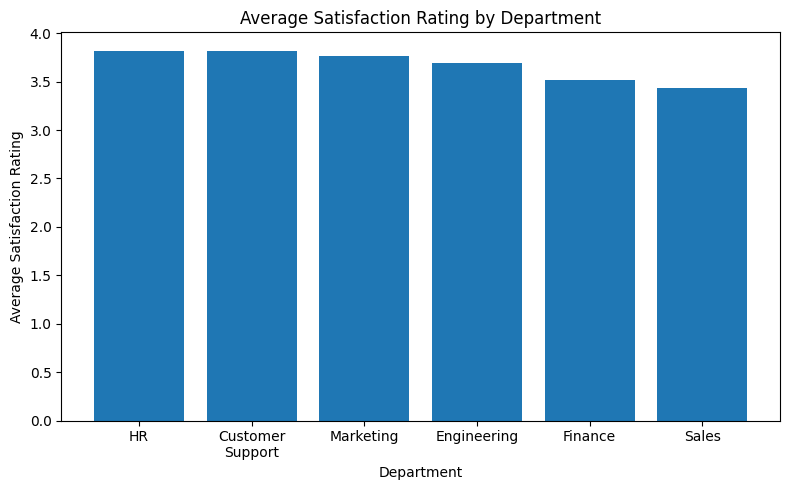

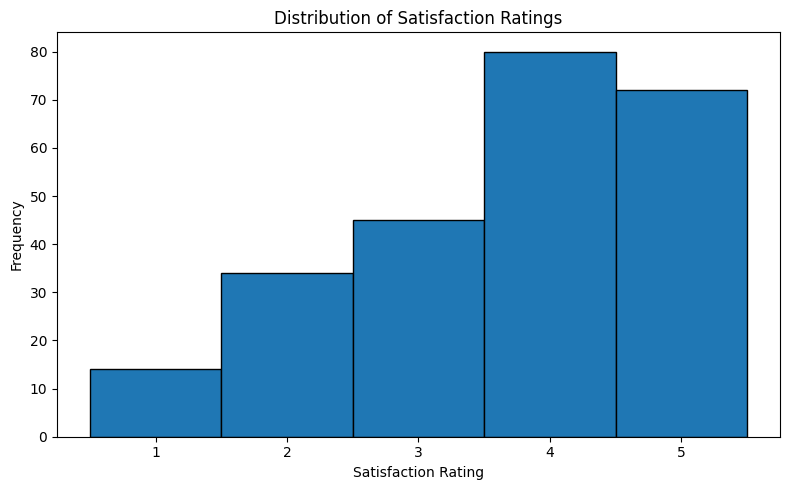

In [311]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: average satisfaction_rating by department (bar chart)
dept_avg = df_clean.groupby('department')['satisfaction_rating'].mean().sort_values(ascending=False)

# shorter, horizontal-friendly labels (display only; df_clean is unchanged)
labels = [d.title().replace('Hr', 'HR').replace(' ', '\n') for d in dept_avg.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, dept_avg.values)
ax.set_title('Average Satisfaction Rating by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Average Satisfaction Rating')
plt.tight_layout()
plt.show()

# Chart 2: distribution of satisfaction_rating (histogram)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['satisfaction_rating'].dropna(), bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_title('Distribution of Satisfaction Ratings')
ax.set_xlabel('Satisfaction Rating')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

---
# 💼 Business Insights
**What did I discover?**

- The raw survey was not safe to use. It had **12** duplicate rows, **8** non-numeric ages, **8** impossible ages, and **6** ratings outside 1–5.
  (원본 설문은 그대로 쓸 수 없었음. 중복 12건, 숫자가 아닌 age 8건, 불가능한 age 8건, 1~5를 벗어난 rating 6건)
- Satisfaction is generally positive: ratings **4** and **5** are the most common, and rating **1** is the rarest.
  (만족도는 대체로 긍정적. 4점과 5점이 가장 많고 1점이 가장 적음)
- Department averages are all between about **3.4** and **3.8**, with Sales lowest and HR and Customer Support highest.
  (부서 평균은 모두 약 3.4~3.8 사이이고 Sales가 가장 낮고 HR과 Customer Support가 가장 높음)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Add input checks to the survey form: numeric age, a 1–5 dropdown for rating, and dropdowns for gender and department. This would prevent the junk and spelling problems.
   (설문 양식에 입력 검증을 추가: age는 숫자만, rating은 1~5 선택, gender와 department는 선택 목록. 문자 값과 표기 불일치를 막을 수 있음)
2. De-duplicate when merging exports from different teams, because **12** duplicate rows appeared.
   (팀별 응답 로그를 합칠 때 중복을 제거. 중복 12건이 나왔기 때문)
3. Look at Sales and Finance first, since they have the lowest averages. But the gaps are small, so confirm before acting.
   (평균이 가장 낮은 Sales와 Finance부터 보기. 다만 차이가 작으므로 행동 전에 확인)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I used `.str.replace` with `None` and with `29`. The replacement must be a string, and `.str` turns real numbers into NaN. `np.where` for `twenty-nine` and then `to_numeric(errors='coerce')` worked.
  (.str.replace에 None과 29를 넣음. 바꿀 값은 문자열이어야 하고 .str은 진짜 숫자를 NaN으로 만듦. twenty-nine은 np.where로, 나머지는 to_numeric(errors='coerce')로 처리)
- I wrote `a < 18 | a > 80` without parentheses. Each condition needs its own parentheses.
  (괄호 없이 `a < 18 | a > 80`을 씀. 조건마다 괄호가 필요)
- I overwrote the raw table, and I compared counts from different bases (with and without duplicates). A separate `df_clean` fixed both.
  (원본을 덮어썼고, 중복 포함/제외 기준이 다른 개수를 비교함. 따로 df_clean을 만들어 해결)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `pd.to_numeric(..., errors='coerce')` turns every non-numeric value into NaN at once. To count the changed rows, compare before and after on the same rows.
  (to_numeric(errors='coerce')는 숫자가 아닌 값을 한 번에 NaN으로 바꿈. 바뀐 행을 세려면 같은 행 기준으로 전후를 비교)
- Impossible values (age 150, rating 8) should become NaN, not be clipped, because clipping invents answers.
  (불가능한 값(age 150, rating 8)은 clip하지 않고 NaN으로 바꿈. clip은 없던 답을 만들기 때문)
- Keep the raw table (`df`) and clean a copy (`df_clean`), so cells can be re-run and before/after can be compared.
  (원본 df는 두고 복사본 df_clean을 정제하면 셀을 다시 실행해도 되고 전후 비교도 가능)
  

---
# 🧠 Reflection

**What was difficult?**
The order of the steps: what to do first, and which steps affect each other.
(코드 순서: 무엇을 먼저 해야 하고, 어떤 단계가 서로 영향을 주는지)

**Why?**
Cleaning changes the data, so a later count can change depending on what ran before it. For example, removing duplicates changes the NaN count, and setting out-of-range values to NaN changes the outlier count.
(정제는 데이터를 바꾸기 때문에 앞에서 무엇을 했는지에 따라 뒤의 개수가 달라짐. 예: 중복을 제거하면 NaN 개수가 달라지고, 범위 밖 값을 NaN으로 바꾸면 이상값 개수가 달라짐)

**How did I solve it?**
Kept the raw table `df`, cleaned a copy `df_clean`, and counted each problem before fixing it. I also took the "before" values from `df` so a cell gives the same result when re-run.
(원본 df는 두고 복사본 df_clean을 정제했고, 고치기 전에 문제 개수를 먼저 셈. 셀을 다시 실행해도 같은 결과가 나오도록 "before" 값은 df에서 가져옴)

**What would I do differently next time?**
Write the order down first: count the problems, copy the table, fix them, then check the result with `describe()`.
(먼저 순서를 적어 두기: 문제 개수 세기, 표 복사, 수정, describe()로 결과 확인)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
Missing values, duplicates, and `to_numeric` cleaning are clear. Choosing how to treat impossible values needed help.  
(결측·중복·to_numeric 정제는 이해. 불가능한 값 처리 방식은 도움 필요)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★☆☆☆☆  
The order of the cleaning steps was the hardest.  
(정제 단계의 순서가 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 18 — Visualization basics (Round 2/5)
  (시각화 기초 복습)
  